# cu_inj Reference simulation

In [1]:
%pylab --no-import-all inline
%config InlineBackend.figure_format = 'retina'

Populating the interactive namespace from numpy and matplotlib


In [4]:
from impact import Impact
from distgen import Generator
import os

NAME = 'impact_cu_inj_v0_300k_particles'

GFILE = os.path.expandvars('$LCLS_LATTICE/distgen/models/cu_inj/v0/distgen.yaml')
YFILE = os.path.expandvars('$LCLS_LATTICE/impact/models/cu_inj/v0/ImpactT.yaml')

In [5]:
%%time
G = Generator(GFILE)
G['n_particle'] = 300_000
G.run()
P0 = G.particles

CPU times: user 2.88 s, sys: 56.7 ms, total: 2.94 s
Wall time: 2.94 s


# MPI run 300k particles

For this many particles we will prepare an MPI run

In [6]:
I = Impact.from_yaml(YFILE)

# Set initial particles
I.initial_particles = P0

## Switches for MPI
I.numprocs = 128
#I.stop = 1.4
I.mpi_run

'mpirun -n {n} {command_mpi}'

In [7]:
# Change some things
I.header['Nx'] = 64
I.header['Ny'] = 64
I.header['Nz'] = 64

# Run on Cori (NERSC)

In [8]:
%%time
I.command_mpi = '/global/homes/c/cmayes/cori/impact/bin/ImpactTv2.1_mpi'
I.workdir = os.path.expandvars('$SCRATCH')
I.mpi_run = 'salloc -N 2 -C haswell -q interactive -t 04:00:00 srun -n {n} {command_mpi} >log.txt' 
I.configure()

I.run()

salloc: Granted job allocation 51325529
salloc: Waiting for resource configuration
salloc: Nodes nid00[164-165] are ready for job
salloc: Relinquishing job allocation 51325529


CPU times: user 26.8 s, sys: 1.62 s, total: 28.4 s
Wall time: 9min 29s


In [9]:
I.path

'/global/cscratch1/sd/cmayes/tmpmwhwit8j'

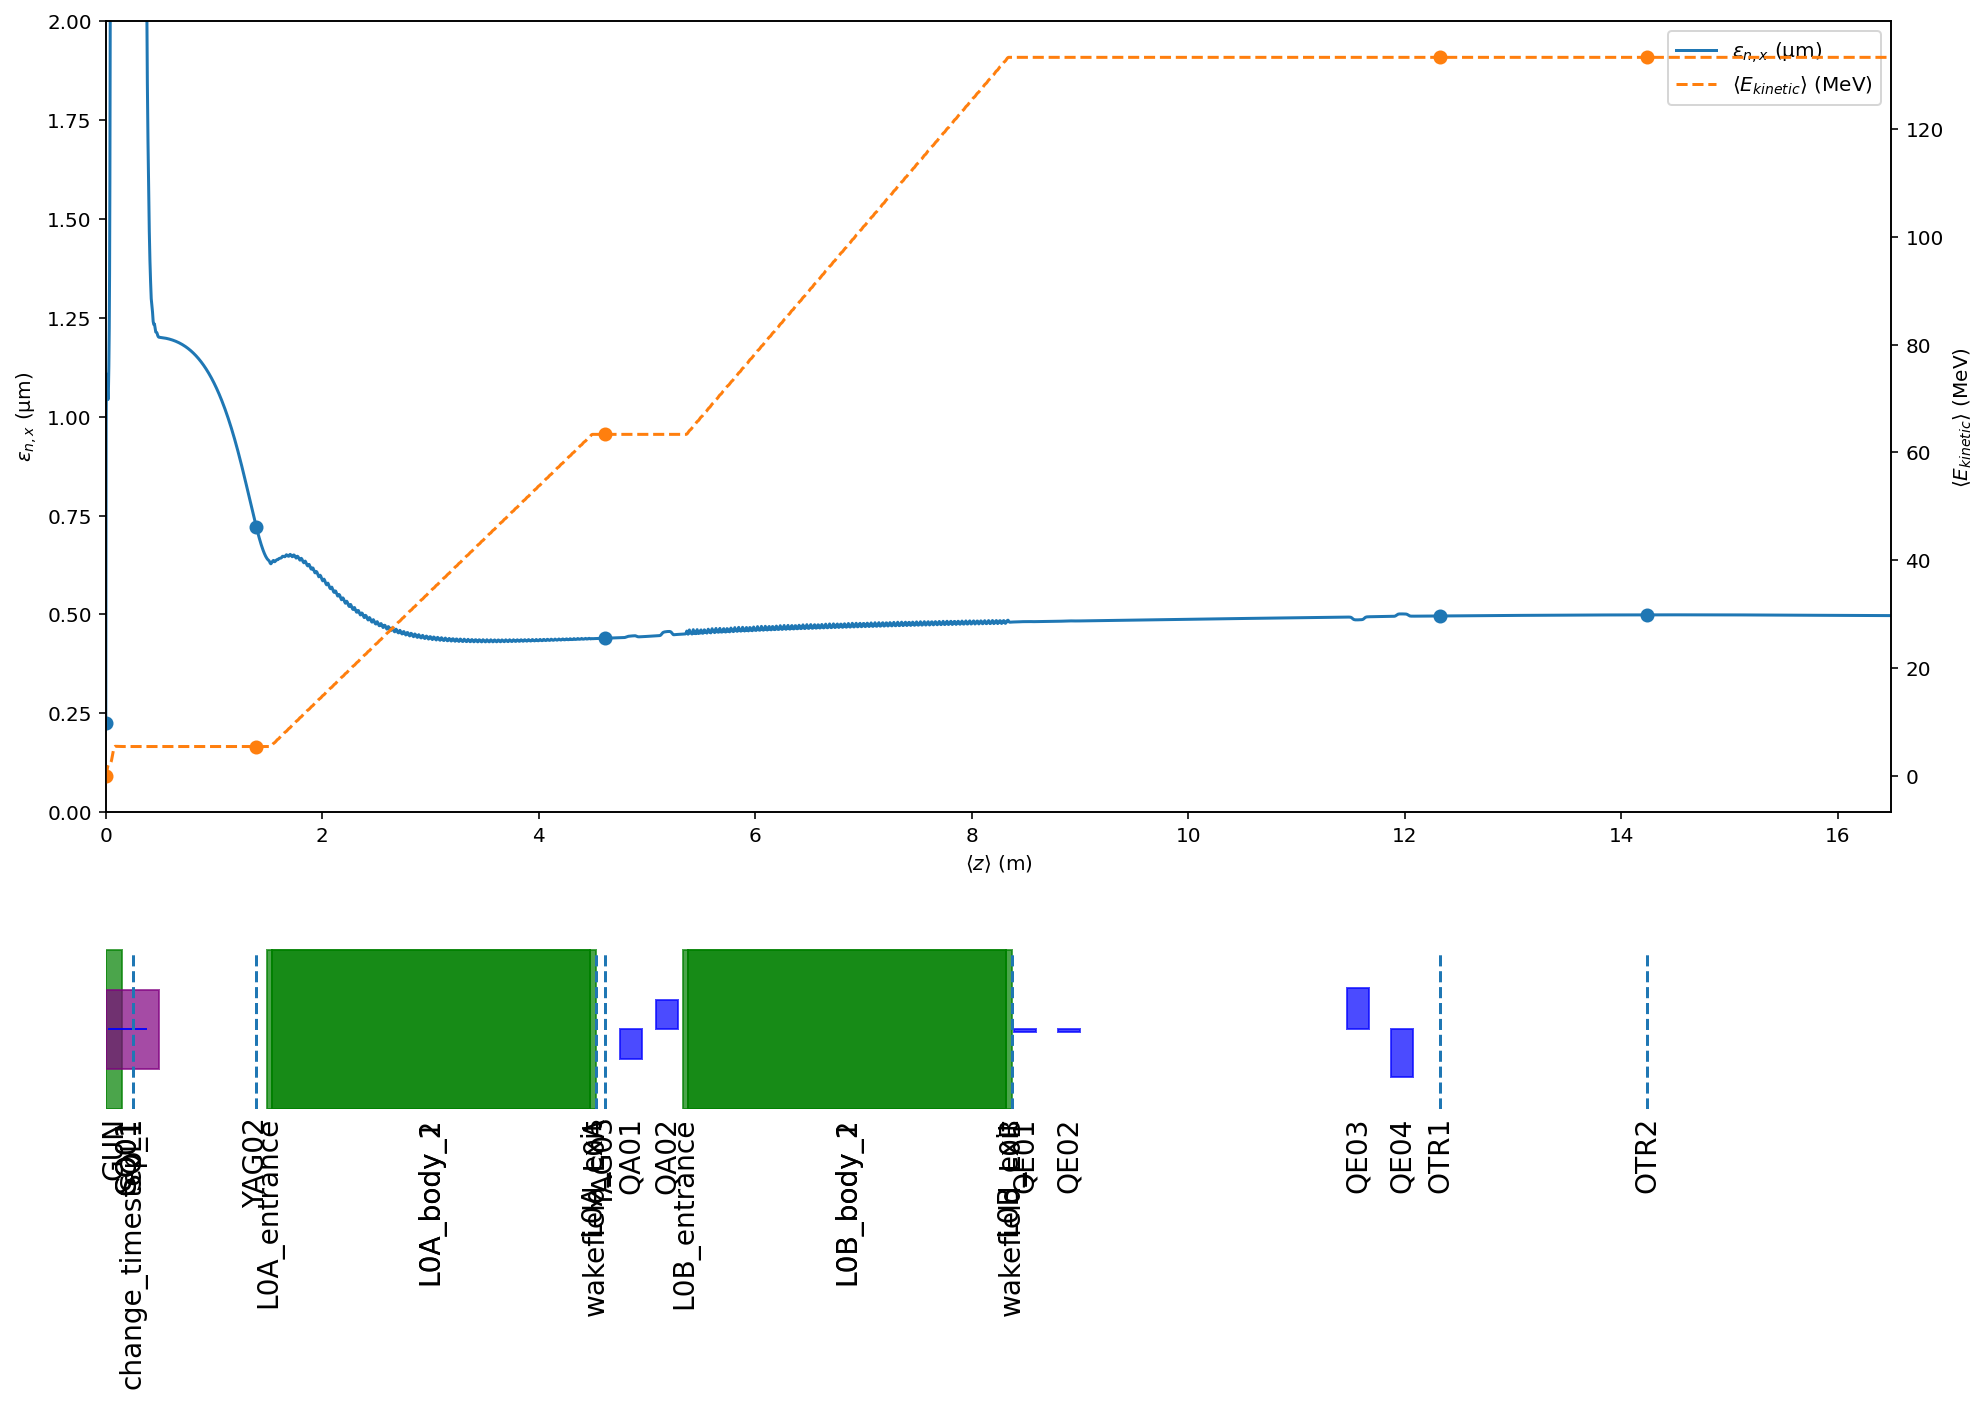

In [10]:
I.plot('norm_emit_x', y2='mean_kinetic_energy', ylim=(0, 2e-6), figsize=(16,10), include_labels=True)

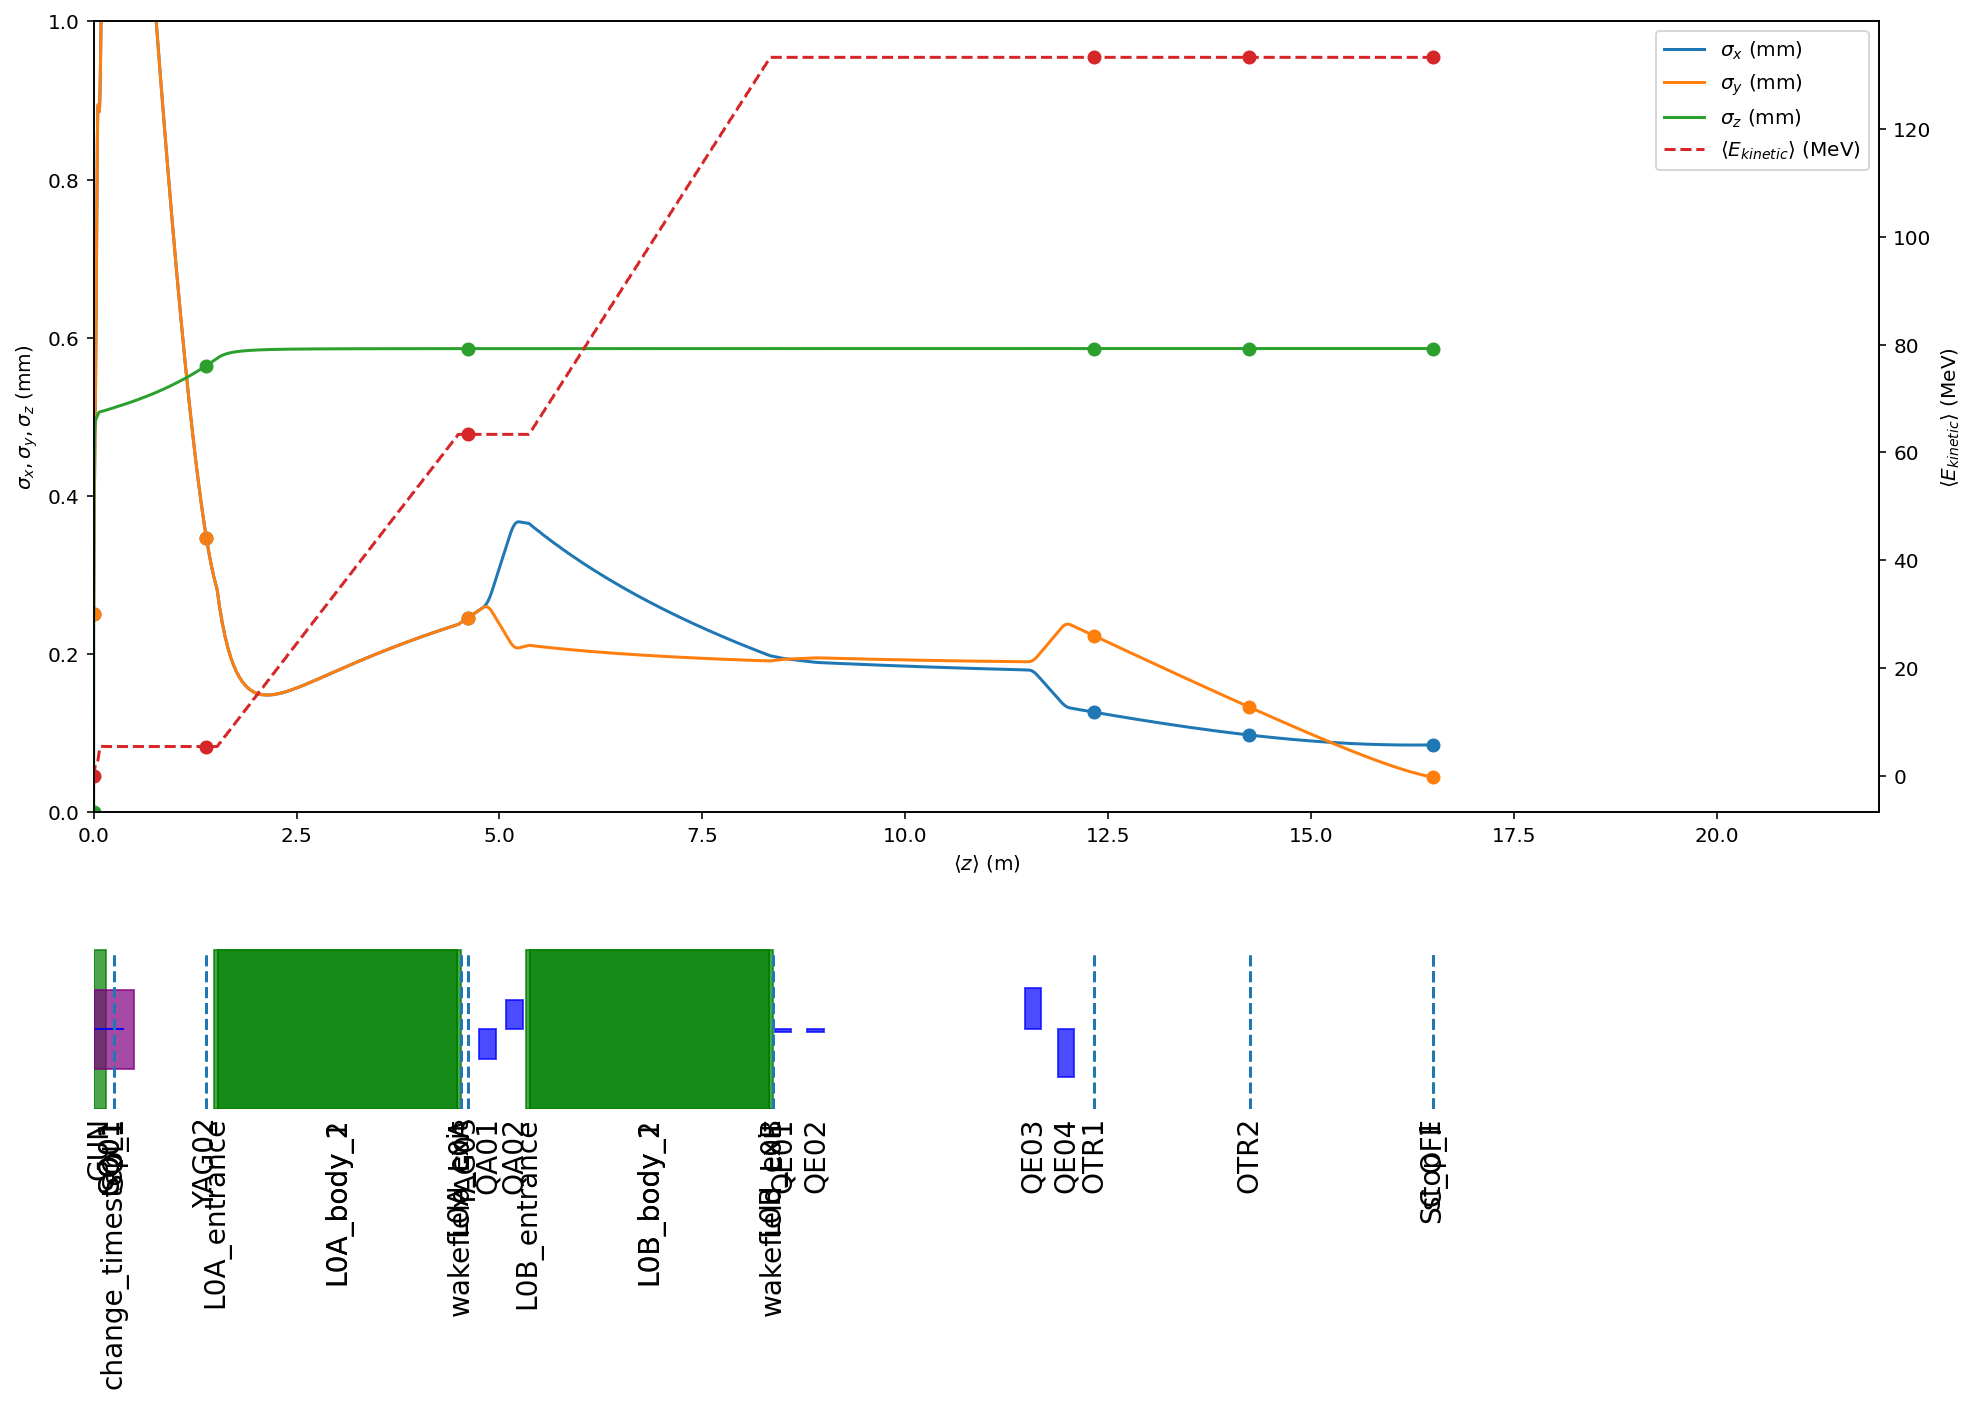

In [11]:
I.plot(['sigma_x', 'sigma_y', 'sigma_z'], y2='mean_kinetic_energy',  ylim=(0, 0.001), xlim=(0, 22), figsize=(16,10), include_labels=True)

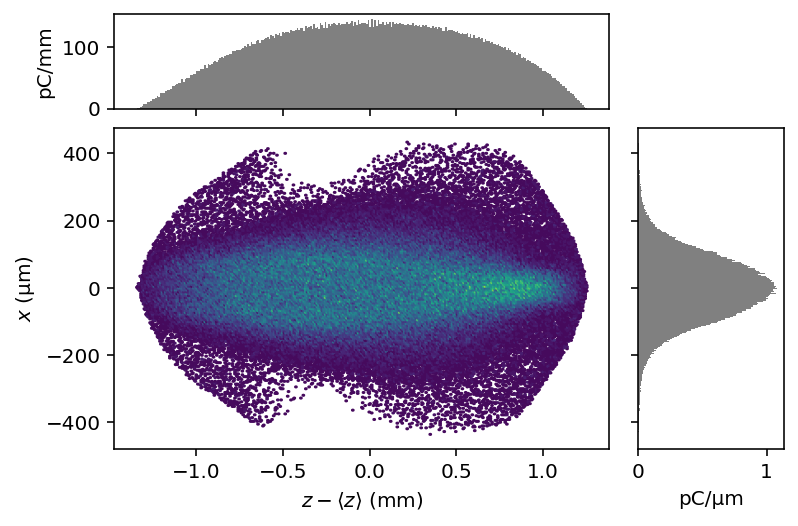

In [12]:
P1 = I.particles['OTR2']

P1.plot('delta_z', 'x')

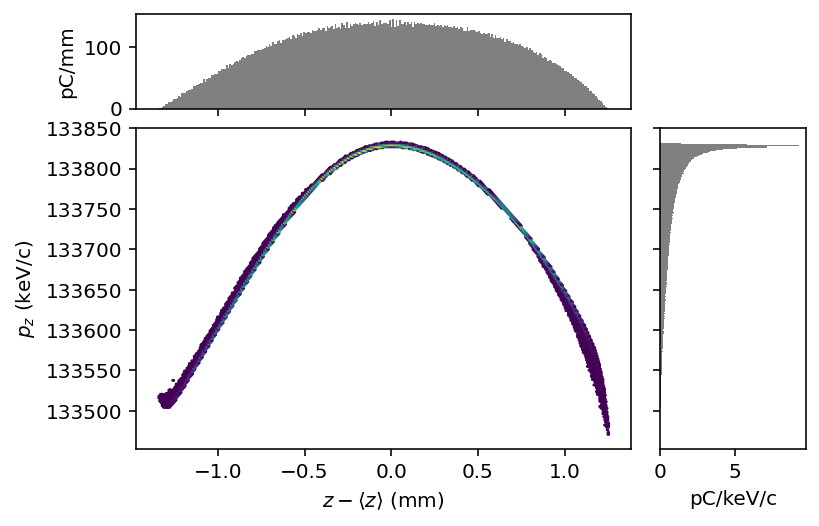

In [13]:
P1.plot('delta_z', 'pz')

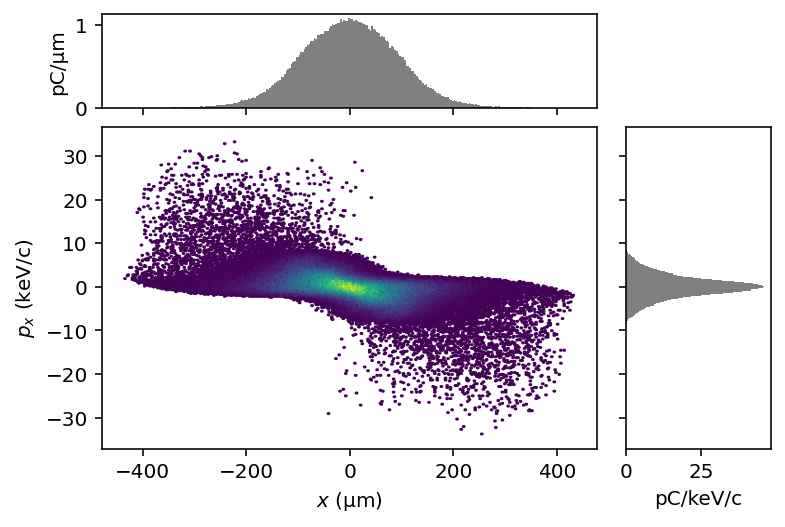

In [14]:
P1.plot('x', 'px')

In [15]:
# 95% Twiss and Emittance
P1.twiss('xy', 0.95)

{'alpha_x': 0.6241942753146622,
 'beta_x': 5.198640847771554,
 'gamma_x': 0.26730419238929903,
 'emit_x': 1.3614233578179004e-09,
 'eta_x': -6.624014735076751e-05,
 'etap_x': -9.98718821805475e-06,
 'norm_emit_x': 3.56362101720654e-07,
 'alpha_y': 3.3168763020077585,
 'beta_y': 9.659498706104774,
 'gamma_y': 1.2424732139811403,
 'emit_y': 1.3288715795195634e-09,
 'eta_y': 2.1477748208985147e-05,
 'etap_y': -3.2695040179437953e-06,
 'norm_emit_y': 3.4784156280073156e-07}

In [13]:
# Copy basic input to `v0/`
#!cp {I.path}/ImpactT.in {os.path.split(YFILE)[0]}
#!cp {I.path}/partcl.data {os.path.split(YFILE)[0]}

In [16]:
# %%time
# afile = f'/global/cfs/cdirs/m669/www/lume/cu_inj/{NAME}.h5'
# I.archive(afile)

CPU times: user 316 ms, sys: 79.8 ms, total: 396 ms
Wall time: 683 ms


'/global/cfs/cdirs/m669/www/lume/cu_inj/impact_cu_inj_v0_300k_particles.h5'

# WWW archive access

In [17]:
# Restore
!wget https://portal.nersc.gov/cfs/m669/lume/cu_inj/impact_cu_inj_v0_300k_particles.h5

--2021-12-01 13:23:02--  https://portal.nersc.gov/cfs/m669/lume/cu_inj/impact_cu_inj_v0_300k_particles.h5
Resolving portal.nersc.gov (portal.nersc.gov)... 128.55.206.108, 128.55.206.110, 128.55.206.106, ...
Connecting to portal.nersc.gov (portal.nersc.gov)|128.55.206.108|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 102173224 (97M)
Saving to: ‘impact_cu_inj_v0_300k_particles.h5.5’

impact_cu_inj_v0_30 100%[===================>]  97.44M   122MB/s    in 0.8s    

2021-12-01 13:23:02 (122 MB/s) - ‘impact_cu_inj_v0_300k_particles.h5.5’ saved [102173224/102173224]



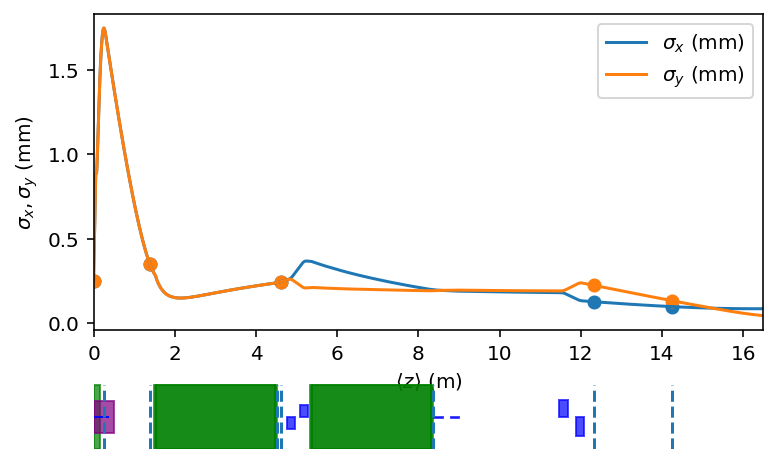

In [18]:
I2 = Impact.from_archive('impact_cu_inj_v0_300k_particles.h5')
I2.plot()